# Movie Genre Classifier

**Goal:** Predict a movie's genre using just a snippet of its script text.

Given a piece of movie script/dialogue, this project builds a machine learning
model that classifies it into one of 9 genres:
`other, action, adventure, comedy, drama, horror, romance, sci-fi, thriller`.

**Approach:**
1. Load and clean the dataset
2. Explore the data (distribution of genres, text stats)
3. Preprocess the text (remove noise, stopwords, stem words)
4. Convert text into numeric features (Bag of Words)
5. Train a Naive Bayes classifier
6. Evaluate accuracy and tune the model
7. Use the model to predict genres on new/unseen scripts

#**Import libraries .**

In [46]:
#Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Text Preprocessing (cleaning + stemming)
import re                                  # regex library, used to remove unwanted characters
import nltk                                # natural language toolkit
nltk.download('stopwords')                 # download list of common filler words (the, is, and, etc.)
from nltk.corpus import stopwords          # import the stopwords list
from nltk.stem.porter import PorterStemmer # import stemmer (reduces words to root form)

#Convert text to numbers (Bag of Words)
from sklearn.feature_extraction.text import CountVectorizer   # tool to convert text into numeric feature vectors

#Split data Train-Test
from sklearn.model_selection import train_test_split   # tool to split data into train/test sets

#Train the model (Naive Bayes)
from sklearn.naive_bayes import MultinomialNB   # Naive Bayes classifier, works well for word-count data

#Evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix   # tools to measure performance

#Word Clouds per Genre.
from wordcloud import WordCloud   # library to generate word cloud images


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#**Load the dataset.**

In [47]:
df = pd.read_csv('train.csv')
df.head()

,id,text,genre
0,0,"eady dead, maybe even wishing he was. INT. 2ND...",thriller
1,2,"t, summa cum laude and all. And I'm about to l...",comedy
2,3,"up Come, I have a surprise.... She takes him ...",drama
3,4,ded by the two detectives. INT. JEFF'S APARTME...,thriller
4,5,"nd dismounts, just as the other children reach...",drama


#**EDA & Data Cleaning.**

#**Basic dataset check.**

In [48]:
# (rows, columns) — how big is our dataset
print("Shape:", df.shape)

# column names, data types, non-null counts
print("\nInfo:")
df.info()

# stats (mean, min, max, etc.) of script text length
print("\nDescribe text length (proxy for numeric describe, since we have no numeric columns yet):")
df['text'].str.len().describe()

Shape: (22579, 3)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22579 entries, 0 to 22578
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      22579 non-null  int64 
 1   text    22579 non-null  object
 2   genre   22579 non-null  object
dtypes: int64(1), object(2)
memory usage: 529.3+ KB

Describe text length (proxy for numeric describe, since we have no numeric columns yet):


,text
count,22579.0
mean,1000.0
std,0.0
min,1000.0
25%,1000.0
50%,1000.0
75%,1000.0
max,1000.0


In [49]:
df.head()


,id,text,genre
0,0,"eady dead, maybe even wishing he was. INT. 2ND...",thriller
1,2,"t, summa cum laude and all. And I'm about to l...",comedy
2,3,"up Come, I have a surprise.... She takes him ...",drama
3,4,ded by the two detectives. INT. JEFF'S APARTME...,thriller
4,5,"nd dismounts, just as the other children reach...",drama


In [50]:
df.tail()

,id,text,genre
22574,28161,n in the world to decide what I'm going to do ...,drama
22575,28162,shards. BOJO LAZ! Laz pushes Deke back through...,drama
22576,28163,"OTTIE You've got a thing about Ernie's, haven'...",thriller
22577,28165,....with marked skill and dexterity . LANA wry...,action
22578,28166,"rd walks off down the hallway, leaving his pos...",comedy


#**Drop useless columns.**

In [51]:
# 'id' is just a row number, unique for every row — no predictive value, so drop it
# inplace=True means it modifies df directly
df.drop('id', axis=1, inplace=True)
# confirm 'id' is gone
df.columns

Index(['text', 'genre'], dtype='object')

#**Handle null values.**

In [52]:
# count of missing (NaN) values per column
df.isnull().sum()

,0
text,0
genre,0


In [53]:
# drop any row where text or genre is missing (should be very few)
df.dropna(inplace=True)
# reset row numbers to 0,1,2... after dropping rows
df.reset_index(drop=True, inplace=True)
df.shape

(22579, 2)

#**Handle duplicates.**

In [54]:
# count rows that are exact duplicates
print("Duplicate rows:", df.duplicated().sum())
# remove those duplicate rows
df.drop_duplicates(inplace=True)
# reset index again after dropping
df.reset_index(drop=True, inplace=True)

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (22579, 2)


#**Check for error/junk values in genre.**

In [55]:
# print all distinct genre labels — look for typos like 'dram' vs 'drama'
df['genre'].unique()

array(['thriller', 'comedy', 'drama', 'action', 'sci-fi', 'other',
       'romance', 'horror', 'adventure'], dtype=object)

#**Univariate analysis (genre distribution).**

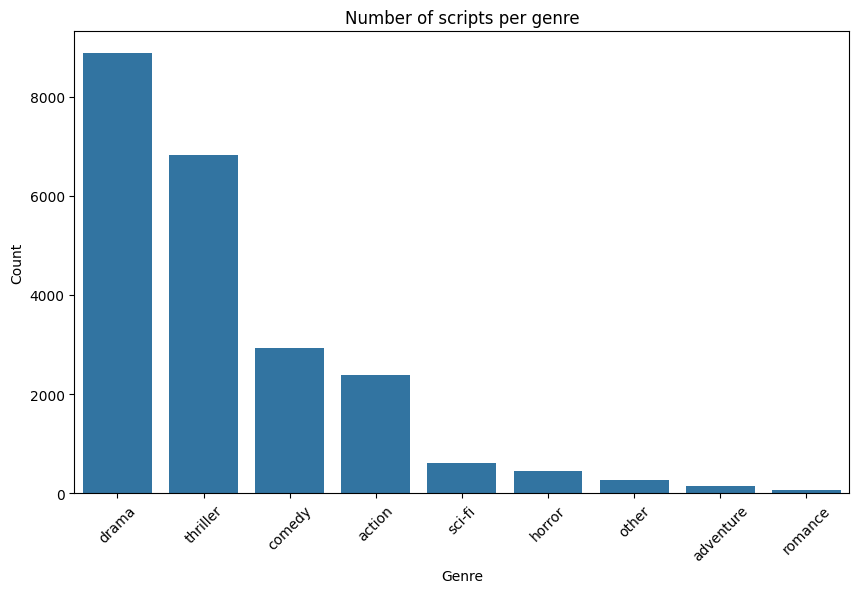

In [56]:
# set plot size (width, height)
plt.figure(figsize=(10,6))
# bar chart of genre counts, sorted by frequency
sns.countplot(x='genre', data=df, order=df['genre'].value_counts().index)
plt.xlabel('Genre')# label x-axis
plt.ylabel('Count')# label y-axis
plt.title('Number of scripts per genre')# chart title
plt.xticks(rotation=45)# rotate genre labels 45° so they don't overlap
plt.show()# render the plot

The model will see drama/thriller scripts far more often, so it gets very good at recognizing them, but barely learns what makes romance or adventure distinct (simply because it doesn't see enough examples.)

#**Text Preprocessing (cleaning + stemming).**

In [57]:
# create stemmer object
ps = PorterStemmer()
# store English stopwords as a set (faster lookup)
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)     # keep only letters, replace everything else (numbers, punctuation) with space
    text = text.lower()                       # convert all text to lowercase
    words = text.split()                      # split sentence into list of words
    words = [ps.stem(w) for w in words if w not in stop_words]  # remove stopwords, then stem remaining words
    return ' '.join(words)                    # join words back into a single cleaned string

corpus = df['text'].apply(clean_text)      # apply cleaning function to every row in 'text' column
corpus[:5]                                 # preview first 5 cleaned entries

,text
0,eadi dead mayb even wish int nd floor hallway ...
1,summa cum laud launch brand new magazin call e...
2,come surpris take hand lead hallway salvator l...
3,ded two detect int jeff apart night medium sho...
4,nd dismount children reach throw arm embrac ch...


#**Word Clouds per Genre.**

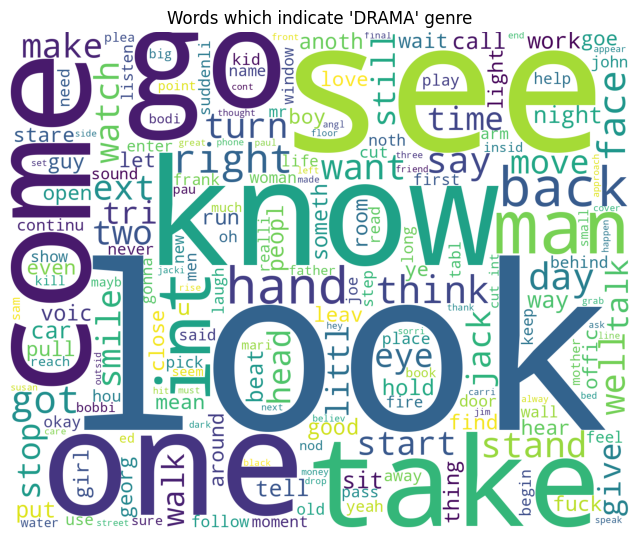

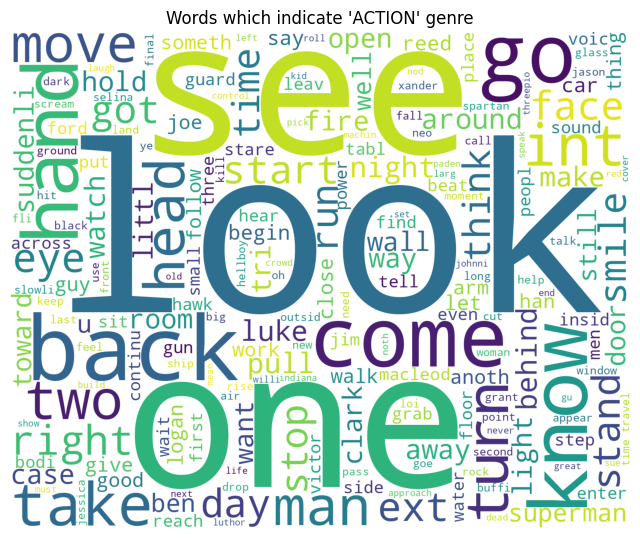

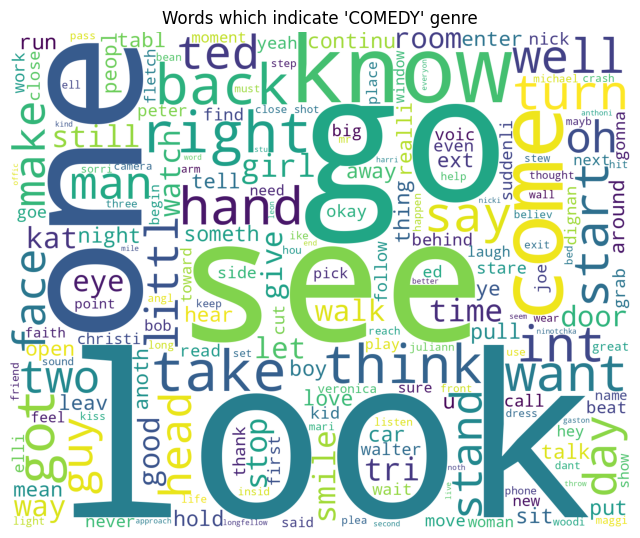

In [68]:
# Pick 3 genres to visualize (feel free to change these numbers using genre_mapper)
genres_to_plot = {'drama': 4, 'action': 1, 'comedy': 3}

for genre_name, genre_num in genres_to_plot.items():
    # get all cleaned script text belonging to this genre
    genre_indices = df[df['genre'] == genre_num].index
    genre_text = ' '.join([corpus[i] for i in genre_indices])

    # generate the word cloud
    wc = WordCloud(background_color='white', width=1500, height=1200).generate(genre_text)

    plt.figure(figsize=(8,8))
    plt.imshow(wc)
    plt.axis('off')
    plt.title(f"Words which indicate '{genre_name.upper()}' genre")
    plt.show()

#**Convert text to numbers (Bag of Words).**

In [58]:
cv = CountVectorizer(max_features=10000, ngram_range=(1,2))   # keep top 10,000 most frequent words/word-pairs (unigrams + bigrams)
X = cv.fit_transform(corpus).toarray()      # learn vocabulary from corpus and convert each script into a vector of word counts

y = df['genre'].values                      # target labels (genre) as a numpy array

print("X shape:", X.shape)                  # (rows, 10000) — each row is now a numeric representation of a script
print("y shape:", y.shape)                  # (rows,) — one genre label per row

X shape: (22579, 10000)
y shape: (22579,)


#**Label encode genres.**

In [59]:
# Map genre text labels to numbers, so the model can work with them
genre_mapper = {
    'other': 0, 'action': 1, 'adventure': 2, 'comedy': 3,
    'drama': 4, 'horror': 5, 'romance': 6, 'sci-fi': 7, 'thriller': 8
}

df['genre'] = df['genre'].map(genre_mapper)   # replace text genre with its number
y = df['genre'].values                        # update y with the numeric labels now

print(df['genre'].unique())    # confirm all values got mapped (no NaNs = no unmapped genre)

[8 3 4 1 7 0 6 5 2]


#**Split data.**

In [60]:
# Split: 80% train, 20% test, random_state=0 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

print("X_train:", X_train.shape)   # training features
print("X_test:", X_test.shape)     # testing features
print("y_train:", y_train.shape)   # training labels
print("y_test:", y_test.shape)     # testing labels

X_train: (18063, 10000)
X_test: (4516, 10000)
y_train: (18063,)
y_test: (4516,)


#**Train the model (Naive Bayes).**

In [61]:
nb_classifier = MultinomialNB()          # create the model
nb_classifier.fit(X_train, y_train)      # train it on training data

MultinomialNB()

#**Evaluate the model.**

In [62]:
y_pred = nb_classifier.predict(X_test)          # predict genres for test set
score = accuracy_score(y_test, y_pred)          # compare predictions to actual answers

print("Accuracy: {}%".format(round(score * 100, 2)))   # print accuracy as a percentage

Accuracy: 89.57%


#**Confusion matrix.**

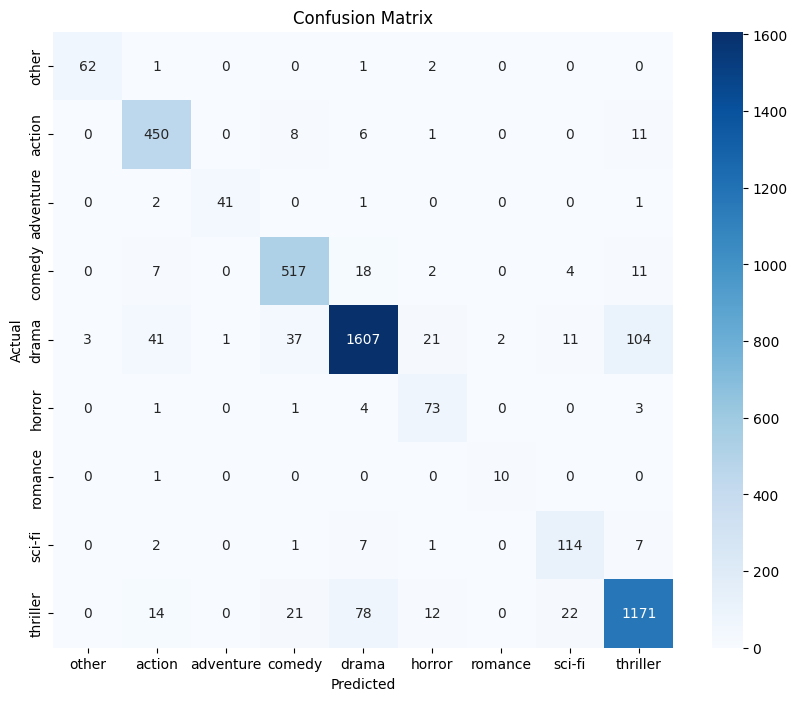

In [63]:
cm = confusion_matrix(y_test, y_pred)    # build confusion matrix (which genres get mixed up)

axis_labels = ['other','action','adventure','comedy','drama','horror','romance','sci-fi','thriller']

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=axis_labels, yticklabels=axis_labels)  # heatmap with numbers shown
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Rows = actual genre, columns = predicted genre. Diagonal = correct predictions.

**Strong genres:** other (62/66 correct), romance (10/11 correct), horror (73/82 correct) — surprisingly good despite low sample size, but small sample size also means these numbers are less statistically reliable.

**Drama:** 1607 correct, but 104 misclassified as thriller, 41 as action — drama is huge in the dataset, so even a small % error rate shows up as a big raw number.

**Thriller:** 1171 correct, but 78 misclassified as drama, 22 as sci-fi — drama and thriller clearly share vocabulary/style (makes sense, thrillers often have dramatic tension scenes).

**Adventure:** only 41 correct, and it's rarely predicted at all — a direct consequence of the class imbalance we saw in Image 2. Same story for sci-fi vs thriller confusion (7 sci-fi scripts predicted as thriller).

#**Tune the model (find best alpha).**

In [64]:
best_accuracy = 0.0    # track best accuracy found so far
best_alpha = 0.0       # track which alpha value gave that accuracy

for alpha in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:   # try different smoothing values
    temp_model = MultinomialNB(alpha=alpha)     # create model with this alpha
    temp_model.fit(X_train, y_train)            # train it
    temp_pred = temp_model.predict(X_test)      # predict on test set
    temp_score = accuracy_score(y_test, temp_pred)   # measure accuracy

    if temp_score > best_accuracy:              # keep track of the best one
        best_accuracy = temp_score
        best_alpha = alpha

print("Best accuracy: {}% at alpha={}".format(round(best_accuracy*100, 2), best_alpha))

Best accuracy: 91.41% at alpha=0.1


#**Train final model using the best alpha found.**

In [65]:
# Train final model using the best alpha found
classifier = MultinomialNB(alpha=best_alpha)
classifier.fit(X_train, y_train)

MultinomialNB(alpha=0.1)

#**Predict genre for any new script.**

In [66]:
def genre_prediction(sample_script):
    sample_script = re.sub('[^a-zA-Z]', ' ', sample_script)   # remove non-letter characters
    sample_script = sample_script.lower()                     # lowercase
    words = sample_script.split()                             # split into words
    words = [ps.stem(w) for w in words if w not in stop_words]  # remove stopwords + stem
    final_text = ' '.join(words)                              # rejoin into a string

    vectorized = cv.transform([final_text]).toarray()   # convert to same 10,000-word numeric format as training data
    prediction = classifier.predict(vectorized)          # predict genre number

    inverse_mapper = {v: k for k, v in genre_mapper.items()}   # flip mapper: number -> genre name
    return inverse_mapper[prediction[0]]                       # return genre name

In [67]:
from random import randint

test = pd.read_csv('test.csv')          # load the unseen test dataset

row = randint(0, test.shape[0] - 1)      # pick a random row
sample_script = test['text'][row]        # get its script text

print("Script snippet:", sample_script[:300], "...")   # print first 300 chars
print("Predicted Genre:", genre_prediction(sample_script))   # run prediction

Script snippet: trunks. Now Leia aims her bike skyward and rises out of sight. The scout turns in confusion, unable to see his pursuer. Suddenly, Leia dives down upon him from above, cannon blasting. The scout's bike takes a glancing hit. Leia moves in alongside him. The scout eyes her beside him, reaches down, and ...
Predicted Genre: action
